# Validation croisée

Réf: https://scikit-learn.org/stable/modules/cross_validation.html

     https://blent.ai/blog/a/validation-croisee-machine-learning

Apprendre les paramètres d'une fonction de prédiction et la tester sur les mêmes données est une erreur méthodologique : un modèle qui se contenterait de répéter les étiquettes des échantillons qu'il vient de voir obtiendrait un score parfait, mais ne parviendrait pas à prédire quoi que ce soit d'utile sur des données encore inconnues. Cette situation est appelée "overfitting". Pour l'éviter, il est courant, lors d'une expérience d'apprentissage automatique (supervisée), de conserver une partie des données disponibles comme ensemble de test X_test, y_test. Pour ce faire, la validation croisée est fréquenmment utilisée. 

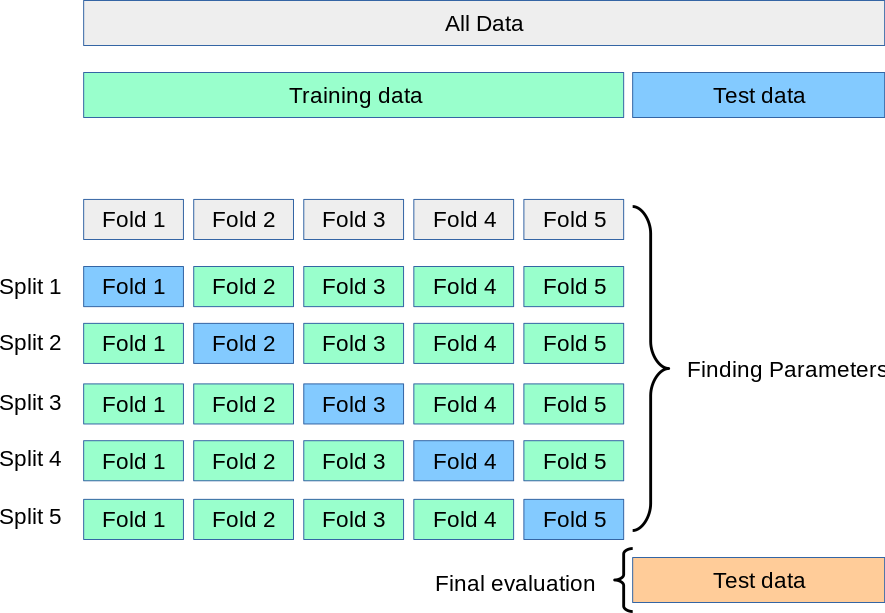


Nous allons implémenter cette technique dans un exemple simple

0. Charger les librairies nécessaires et la base de données "California_housing_data.csv"



In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('California_housing_data.csv')

Description de la database:

California Housing dataset
--------------------------

**Data Set Characteristics:**

    :Number of Instances: 20640

    :Number of Attributes: 8 numeric, predictive attributes and the target

    :Attribute Information:
        - MedInc        median income in block group
        - HouseAge      median house age in block group
        - AveRooms      average number of rooms per household
        - AveBedrms     average number of bedrooms per household
        - Population    block group population
        - AveOccup      average number of household members
        - Latitude      block group latitude
        - Longitude     block group longitude

    :Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per census
block group. A block group is the smallest geographical unit for which the U.S.
Census Bureau publishes sample data (a block group typically has a population
of 600 to 3,000 people).

A household is a group of people residing within a home. Since the average
number of rooms and bedrooms in this dataset are provided per household, these
columns may take surprisingly large values for block groups with few households
and many empty houses, such as vacation resorts.

It can be downloaded/loaded using the
:func:`sklearn.datasets.fetch_california_housing` function.

.. topic:: References

    - Pace, R. Kelley and Ronald Barry, Sparse Spatial Autoregressions,
      Statistics and Probability Letters, 33 (1997) 291-297

1. Analyser la base de données 

Vous êtes libres à donner la réponse. Suggestions: afficher par exemple les statistiques de données, hitogramme, pairplot...

      Unnamed: 0   MedInc  HouseAge  AveRooms  AveBedrms  Population  \
0.25     5159.75  2.56340      18.0  4.440716   1.006079       787.0   
0.50    10319.50  3.53480      29.0  5.229129   1.048780      1166.0   
0.75    15479.25  4.74325      37.0  6.052381   1.099526      1725.0   

      AveOccup  Latitude  Longitude    price  
0.25  2.429741     33.93    -121.80  1.19600  
0.50  2.818116     34.26    -118.49  1.79700  
0.75  3.282261     37.71    -118.01  2.64725  


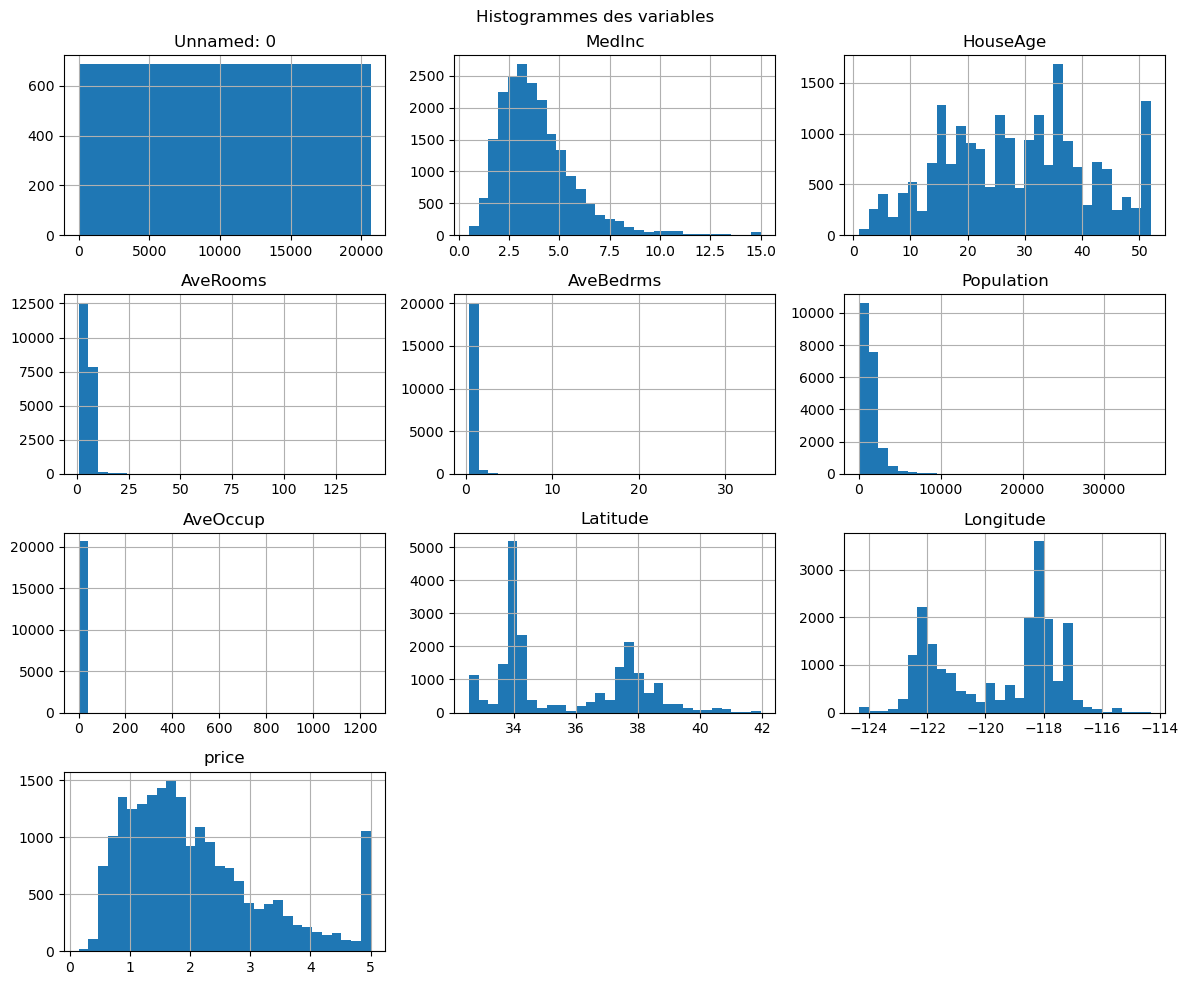

In [8]:
print(df.quantile([0.25, 0.5, 0.75]))
df.hist(figsize=(12, 10), bins=30)
plt.suptitle("Histogrammes des variables")
plt.tight_layout()
plt.show()

On va ensuite étudier le modèle "arbre de décision" pour prédire le prix de la maison

Quelques informations sur ce modèle:

https://scikit-learn.org/stable/modules/tree.html

https://www.ibm.com/fr-fr/topics/decision-trees#:~:text=Un%20arbre%20de%20d%C3%A9cisions%20est,internes%20et%20de%20n%C5%93uds%20feuille.


A noter que l'objet de cette étude est la validation croisée, pas besoin de tout comprendre sur les arbres de décision pour le moment.

2. Séparation train/test

3. Entrainer l'arbre de décision avec les données "train"

In [14]:
from sklearn.tree import DecisionTreeRegressor



4. Afficher MAE pour train et pour test. Votre remarque?

5. Refaire les questions 2-3-4 mais avec une séparation train/test différente (changer random_state). Que remarquez-vous sur les valeurs MAE obtenues de la question 4 pour ces 2 lancements

6. Pour mieux évaluer les performances du modèle dans le cas général, on va utiliser cross_validate

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate



In [ ]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    regressor, data, target, cv=20, scoring="neg_mean_absolute_error"
)

7. Construire un dataframe à partir de cv_results, afficher-le

8. Ajouter une colonne, nommée "test_error" en reprenant la colonne "test_score" mais en mettant le signe "-" devant chaque valeur. Afficher le dataframe modifié qui contient désormais 4 colonnes

9. Tracer l'histogramme des erreurs MAE. Déterminer la valeur moyenne et l'écart type des erreurs

10. En traçant l'histogramme des prix de maisons, commenter sur les performances du modèle 'decision tree'